In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [70]:
def getCSV(csv):
    dfl = pd.read_csv(csv)
    return dfl
df = getCSV(r'C:\Users\Tom\OneDrive\Documents\APROJECTS\NationalityPupilsCompare.csv') 

In [71]:
def changeNames(name):
    switch = {
        "United Kingdom (1)": "UK",
        "United States and Canada":"USA\nCan",
        "Other Europe(32)": "Other\nEurope",
        "Other America (1)": "Other\nAmerica",
        "Australia and South Pacific": "Aus\nNZ",
        "EU 15 excluding Ireland and United Kingdom": "EU\n15",
        'EU 13': 'EU\n13',
        "Asia and Middle East": "Asia\nME",
        "Africa (11)": "Africa",
        "Other countries": "Other"
    }
    if name not in switch:
        return name
    else:
        return switch[name]
    
df['Nationality of Pupil'] = df['Nationality of Pupil'].apply(changeNames)
print(list(set(df['Nationality of Pupil'])))

['Asia\nME', 'Other\nEurope', 'USA\nCan', 'All countries', 'Other\nAmerica', 'EU\n15', 'Africa', 'Ireland', 'EU\n13', 'Other', 'UK', 'Aus\nNZ']


In [72]:
year1 = "2016-2017"
year2 = "2023-2024"
filtered_df = df[(df['County']=="All Counties")&(df['Nationality of Pupil']!='All countries')&(df['Nationality of Pupil']!='Ireland')]
year1_df = filtered_df[filtered_df['Academic Year']==year1]
year2_df = filtered_df[filtered_df['Academic Year']==year2]

print(year2_df)

                                   Statistic Label        County  \
15  Nationality of Pupils attending Primary School  All Counties   
31  Nationality of Pupils attending Primary School  All Counties   
39  Nationality of Pupils attending Primary School  All Counties   
47  Nationality of Pupils attending Primary School  All Counties   
55  Nationality of Pupils attending Primary School  All Counties   
63  Nationality of Pupils attending Primary School  All Counties   
71  Nationality of Pupils attending Primary School  All Counties   
79  Nationality of Pupils attending Primary School  All Counties   
87  Nationality of Pupils attending Primary School  All Counties   
95  Nationality of Pupils attending Primary School  All Counties   

   Nationality of Pupil Academic Year    UNIT  VALUE  
15                   UK     2023-2024  Number   3043  
31             USA\nCan     2023-2024  Number   1322  
39               Africa     2023-2024  Number   7483  
47             Asia\nME     202

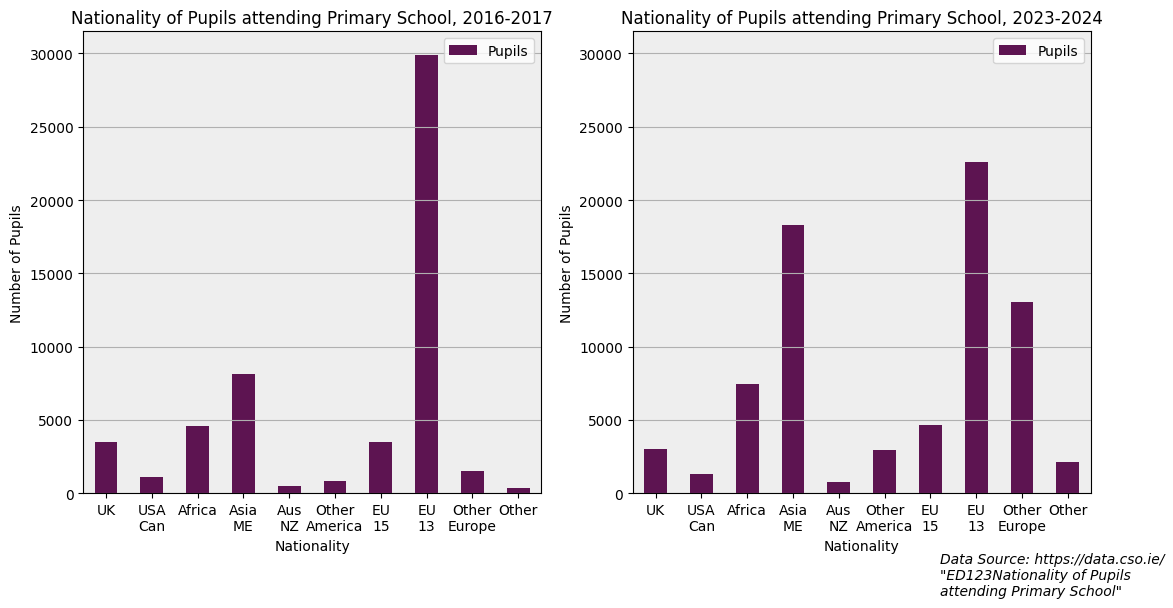

In [83]:
fig, ax = plt.subplots(1, 2, figsize=(13, 6))

year1_df.plot(x="Nationality of Pupil", y="VALUE", kind="bar", color="#5D1451", ax=ax[0], label="Pupils")
year2_df.plot(x="Nationality of Pupil", y="VALUE", kind="bar", color="#5D1451", ax=ax[1], label="Pupils")

ax[0].set_title("Nationality of Pupils attending Primary School, "+year1)
ax[0].set_xlabel("Nationality")
ax[0].set_ylabel("Number of Pupils")
ax[0].set_ylim(0, 31500)
ax[0].tick_params(axis='x', rotation=0)
ax[0].set_facecolor('#EEEEEE')
ax[0].grid(axis='y')

ax[1].set_title("Nationality of Pupils attending Primary School, "+year2)
ax[1].set_xlabel("Nationality")
ax[1].set_ylabel("Number of Pupils")
ax[1].set_ylim(0, 31500)
ax[1].tick_params(axis='x', rotation=0)
ax[1].set_facecolor('#EEEEEE')
ax[1].grid(axis='y')
plt.text(0.67, -0.22, "Data Source: https://data.cso.ie/\n\"ED123Nationality of Pupils \nattending Primary School\" ", ha='left',
         transform=ax[1].transAxes, fontdict={'fontstyle': 'italic', 'fontsize': 10})

save_fig = 'nationalityPrimarySchool'+year1+year2+'.png'
plt.savefig(save_fig, bbox_inches="tight")

# Show the plot
plt.show()